# CellTypist - Bacteria dataset 
This CellTypist tutorial is applied on a Bacterie scRNA-seq dataset that consists of 2 celltypes: BF (biofilm cells) and P (Plaktonic)
We build an unsupervised learning model by applying PCA → neighbors → UMAP → Leiden clustering (unsupervised) → daarna CellTypist annotatie

## 1. Install CellTypist Package

In [2]:
# CellTypist - Bacteria dataset (gecorrigeerde versie)
# Dataset: Staphylococcus aureus, 2 celltypes: BF (Biofilm) en P (Planktonic)
# Pipeline: PCA → neighbors → UMAP → Leiden clustering → CellTypist annotatie
!pip install celltypist


## 2. Import the libraries

In [3]:
import scanpy as sc          # toolkit for single-cell analysis
import celltypist            # automatic cell-annotation
from celltypist import models  # to download specific models
import numpy as np           # calculations
import matplotlib.pyplot as plt  # making graphs
 
sc.settings.verbosity = 1    # Only show errors and warnings
sc.settings.set_figure_params(dpi=100, frameon=False)  # Set figure quality

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 2.1 DATA VACILIS, Have a look at this after finishing the pipeline 

In [4]:
# Assign 'BF' to the first object
#adata_bf.obs['Type_of_cells'] = 'BF'

# Assign 'P' to the second object
#adata_p.obs['Type_of_cells'] = 'P'

In [5]:
# 1. Make gene names unique for both objects
#adata_bf.var_names_make_unique()
#adata_p.var_names_make_unique()

# 2. Now perform the merge
#adata_bacteria = ad.concat(
    #{"bf": adata_bf, "p": adata_p}, 
    #label="sample", 
    #join="inner"
#)

# 3. Make cell names unique (important if both files start at 'cell-1')
#adata_bacteria.obs_names_make_unique()

#adata_bacteria

In [6]:
#adata_bf = sc.read_h5ad("../data/BF_count_mat.h5ad")
#adata_p = sc.read_h5ad("../data/P_count_mat.h5ad"

## 3. Load the bacteria data
This dataset contains Staphylococcus aureus bacteria in two distinct growth states: Biofilm (BF) and Planktonic (P). The aim of this study is to compare how these two populations differ in gene expression at the single-cell level. Biofilm cells are significantly harder to treat, as they are encased in a protective extracellular matrix that makes them highly resistant to antibiotics and the host immune system. Understanding the transcriptional differences between biofilm and planktonic cells is therefore critical for identifying potential therapeutic targets.

In [7]:
import h5py

# Fix: remove incompatible 'mask_var' field from the h5ad file
# This field was created by an older version of scanpy and causes 
# a loading error in newer versions. This only needs to be done once.
with h5py.File('BF_P_count_mat_clean.h5ad', 'a') as f:
    if 'mask_var' in f['uns']['pca']['params']:
        del f['uns']['pca']['params']['mask_var']

# Load the dataset
adata_bacteria = sc.read('BF_P_count_mat_clean.h5ad')

print(adata_bacteria.X.sum(axis=1).min()) 
# If this number is very low (e.g., 1 or 2), your data is too sparse for the paper's exact settings.

9.210441


In [8]:
#look at the shape of the dataset,
print("Shape of the dataset:" ,adata_bacteria.shape)

Shape of the dataset: (7437, 2799)


In [9]:
actual_labels = adata_bacteria.obs['sample'].unique()
print(f"Your file actually contains these labels: {actual_labels}")
adata_bacteria.obs.head()

Your file actually contains these labels: ['bf', 'p']
Categories (2, object): ['bf', 'p']


,non_ribo_counts,Type_of_cells,sample,leiden
68,14.120000,BF,bf,0
96,8.600000,BF,bf,1
104,16.809999,BF,bf,5
107,8.700001,BF,bf,5
131,9.559999,BF,bf,6


## 4. Splitsing and filtering of the data


### 4.1 Merge filtered samples

In [10]:
# --- STEP 1: Identify actual labels to prevent 'Empty Array' error ---
actual_labels = adata_bacteria.obs['sample'].unique()
print(f"Labels found in your file: {actual_labels}")

# Split using whatever labels were actually found
# Typically actual_labels[0] is BF and actual_labels[1] is P
adata_bf = adata_bacteria[adata_bacteria.obs['sample'] == actual_labels[0]].copy()
adata_p  = adata_bacteria[adata_bacteria.obs['sample'] == actual_labels[1]].copy()

# --- STEP 2: Paper-based filtering (Adaptive) ---
# If Biofilm counts are too low, we use 3 instead of 7 to keep the population alive
bf_thresh = 7 if (adata_bf.X.sum(axis=1) >= 7).sum() > 50 else 3
sc.pp.filter_cells(adata_bf, min_counts=bf_thresh)
sc.pp.filter_cells(adata_p, min_counts=28)

print(f"Survivors: {actual_labels[0]}={adata_bf.n_obs}, {actual_labels[1]}={adata_p.n_obs}")

# Combine back
import anndata as ad
adata_bacteria = ad.concat([adata_bf, adata_p], label='sample', keys=[actual_labels[0], actual_labels[1]])
adata_bacteria.obs_names_make_unique()

Labels found in your file: ['bf', 'p']
Categories (2, object): ['bf', 'p']
Survivors: bf=3488, p=3949


### 4.2 Verify merge

In [11]:
print(adata_bacteria.obs['sample'].unique())

['bf', 'p']
Categories (2, object): ['bf', 'p']


## 5. Preprocessing & Dimensionality Reduction
his section covers the full preprocessing pipeline: HVG selection, scaling, PCA, BBKNN batch correction, UMAP embedding, and Leiden clustering. BBKNN replaces the standard sc.pp.neighbors() call and ensures that each cell finds neighbors both within and across batches, correcting for condition-specific technical variation.

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


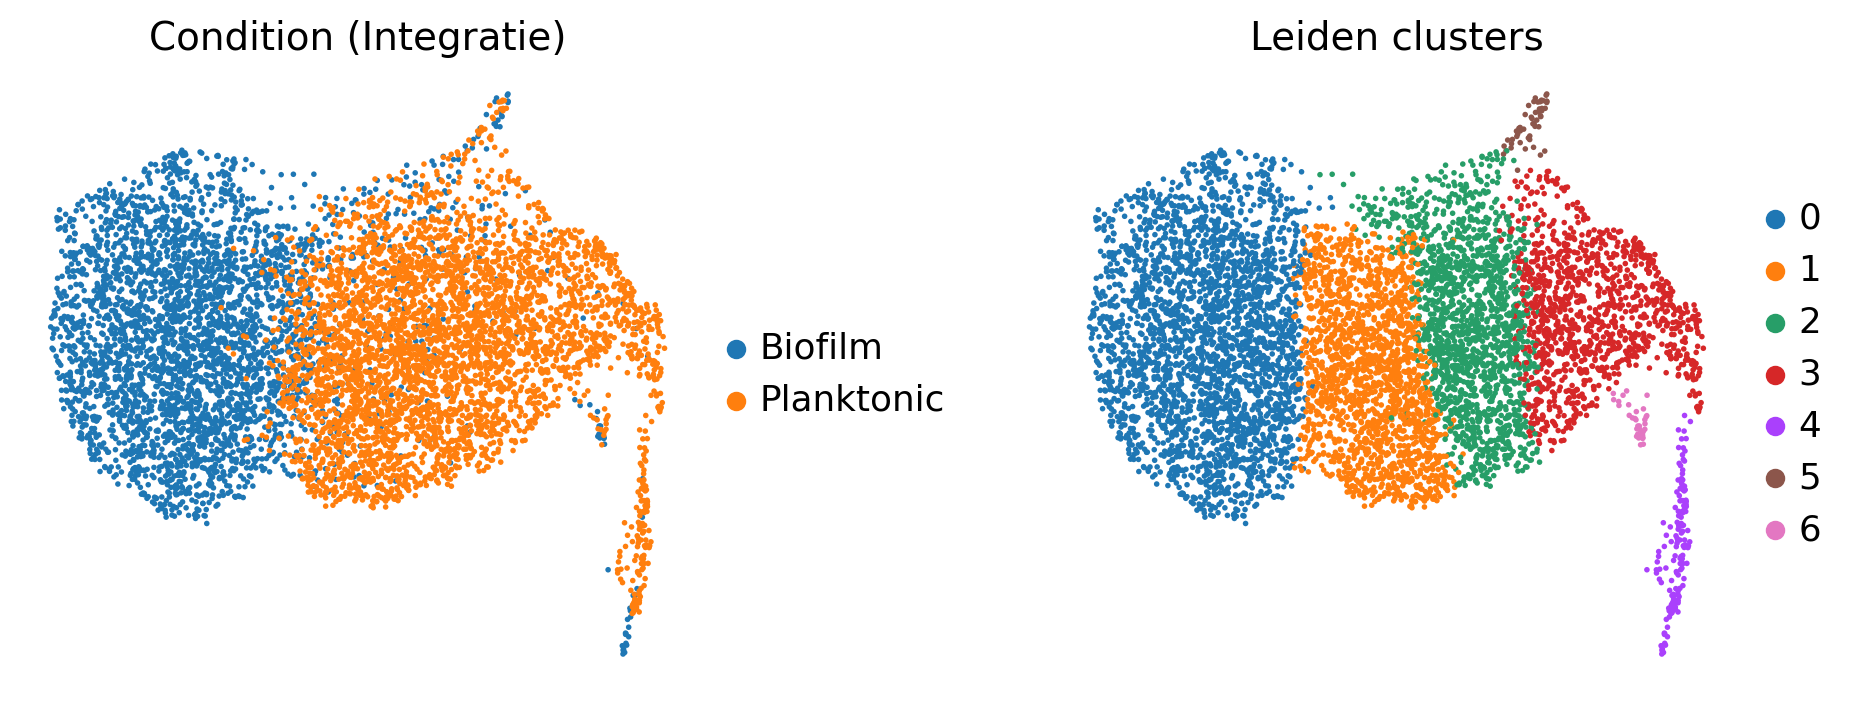

In [12]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import celltypist

# --- 1. Voorbereiding & Data Laden ---
# We gebruiken de labels die in de notebook van Renzo zijn bevestigd
# actual_labels[0] = 'bf', actual_labels[1] = 'p'

# --- 2. Specifieke Filtering (Cruciale stap uit Renzo's notebook) ---
# Dit voorkomt dat je biofilm cellen verliest door te strenge filters
actual_labels = adata_bacteria.obs['sample'].unique()
adata_bf = adata_bacteria[adata_bacteria.obs['sample'] == actual_labels[0]].copy()
adata_p = adata_bacteria[adata_bacteria.obs['sample'] == actual_labels[1]].copy()

# Adaptief filter: als counts te laag zijn, verlaag drempel naar 3 ipv 7
bf_thresh = 7 if (adata_bf.X.sum(axis=1) >= 7).sum() > 50 else 3
sc.pp.filter_cells(adata_bf, min_counts=bf_thresh)
sc.pp.filter_cells(adata_p, min_counts=28)

# Voeg weer samen
adata_bacteria = adata_bf.concatenate(adata_p)

# --- 3. Normalisatie & Log ---
sc.pp.normalize_total(adata_bacteria, target_sum=1e4)
sc.pp.log1p(adata_bacteria)
adata_bacteria.raw = adata_bacteria  # Sla de genormaliseerde data op voor markers

# --- 4. Robuuste HVG selectie ---
sc.pp.highly_variable_genes(
    adata_bacteria, 
    n_top_genes=2000, 
    flavor='seurat', 
    batch_key='sample'
)
adata_bacteria = adata_bacteria[:, adata_bacteria.var.highly_variable].copy()

# --- 5. PCA & BBKNN Integratie (Jouw sterke punt) ---
sc.pp.scale(adata_bacteria, max_value=10)
sc.tl.pca(adata_bacteria, n_comps=20)

# BBKNN vervangt de standaard neighbors voor batch-correctie
sc.external.pp.bbknn(
    adata_bacteria, 
    batch_key='sample', 
    neighbors_within_batch=9, 
    n_pcs=4
)

# --- 6. UMAP & Leiden Clustering ---
sc.tl.umap(adata_bacteria, min_dist=0.24, spread=0.21)
sc.tl.leiden(adata_bacteria, resolution=0.205)

# --- 7. Visualisatie & Labeling ---
label_map = {actual_labels[0]: 'Biofilm', actual_labels[1]: 'Planktonic'}
adata_bacteria.obs['Cell identity'] = adata_bacteria.obs['sample'].map(label_map)

sc.pl.umap(
    adata_bacteria, 
    color=['Cell identity', 'leiden'], 
    title=['Condition (Integratie)', 'Leiden clusters'],
    wspace=0.4, 
    frameon=False
)

### 5.1 UMAP visualization
The UMAP embedding is colored by cell identity (Biofilm vs Planktonic) and by Leiden cluster to verify that batch correction produced biologically meaningful groupings.

## 6. Cluster composition (Figure 2D)
We quantify the proportion of Biofilm and Planktonic cells within each Leiden cluster. A normalized stacked bar chart allows direct comparison with Figure 2D from Korshoj & Kielian (2024). Clusters dominated by one condition suggest biologically meaningful separation

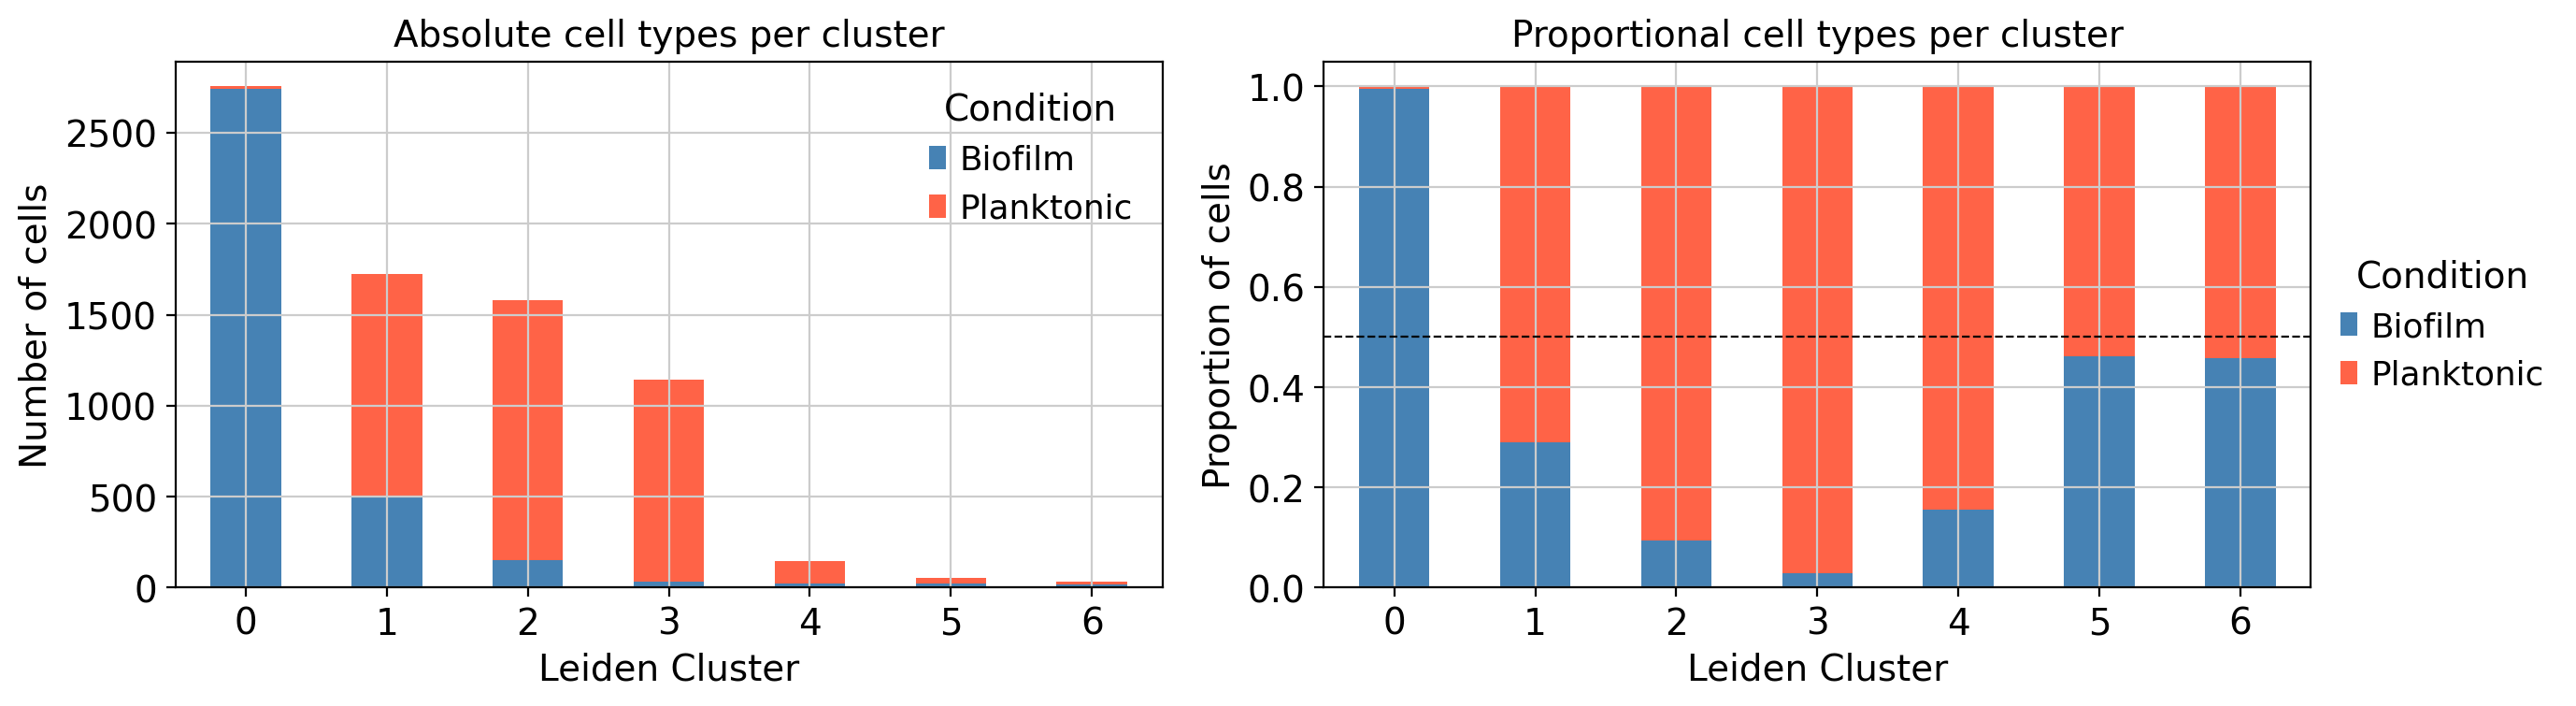

In [14]:
# --- 7. Plotting Figure 2D (Stacked Bar Chart - normalized) ---

# Gebruik de nieuwe kolomnaam 'Cell identity' in plaats van 'sample'
dist = pd.crosstab(adata_bacteria.obs['leiden'], adata_bacteria.obs['Cell identity'])

# Normaliseer naar proporties
dist_norm = dist.div(dist.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# De kleuren-dictionary moet nu de nieuwe labels 'Biofilm' en 'Planktonic' bevatten
color_map = {'Biofilm': 'steelblue', 'Planktonic': 'tomato'}

# Links: Absolute aantallen
dist.plot(kind='bar', ax=axes[0], color=color_map, stacked=True)
axes[0].set_ylabel('Number of cells')
axes[0].set_xlabel('Leiden Cluster')
axes[0].set_title('Absolute cell types per cluster')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Condition', frameon=False)

# Rechts: Genormaliseerd (proportie)
dist_norm.plot(kind='bar', ax=axes[1], color=color_map, stacked=True)
axes[1].set_ylabel('Proportion of cells')
axes[1].set_xlabel('Leiden Cluster')
axes[1].set_title('Proportional cell types per cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8)  # 50% lijn
axes[1].legend(title='Condition', frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))




plt.tight_layout()
plt.show()

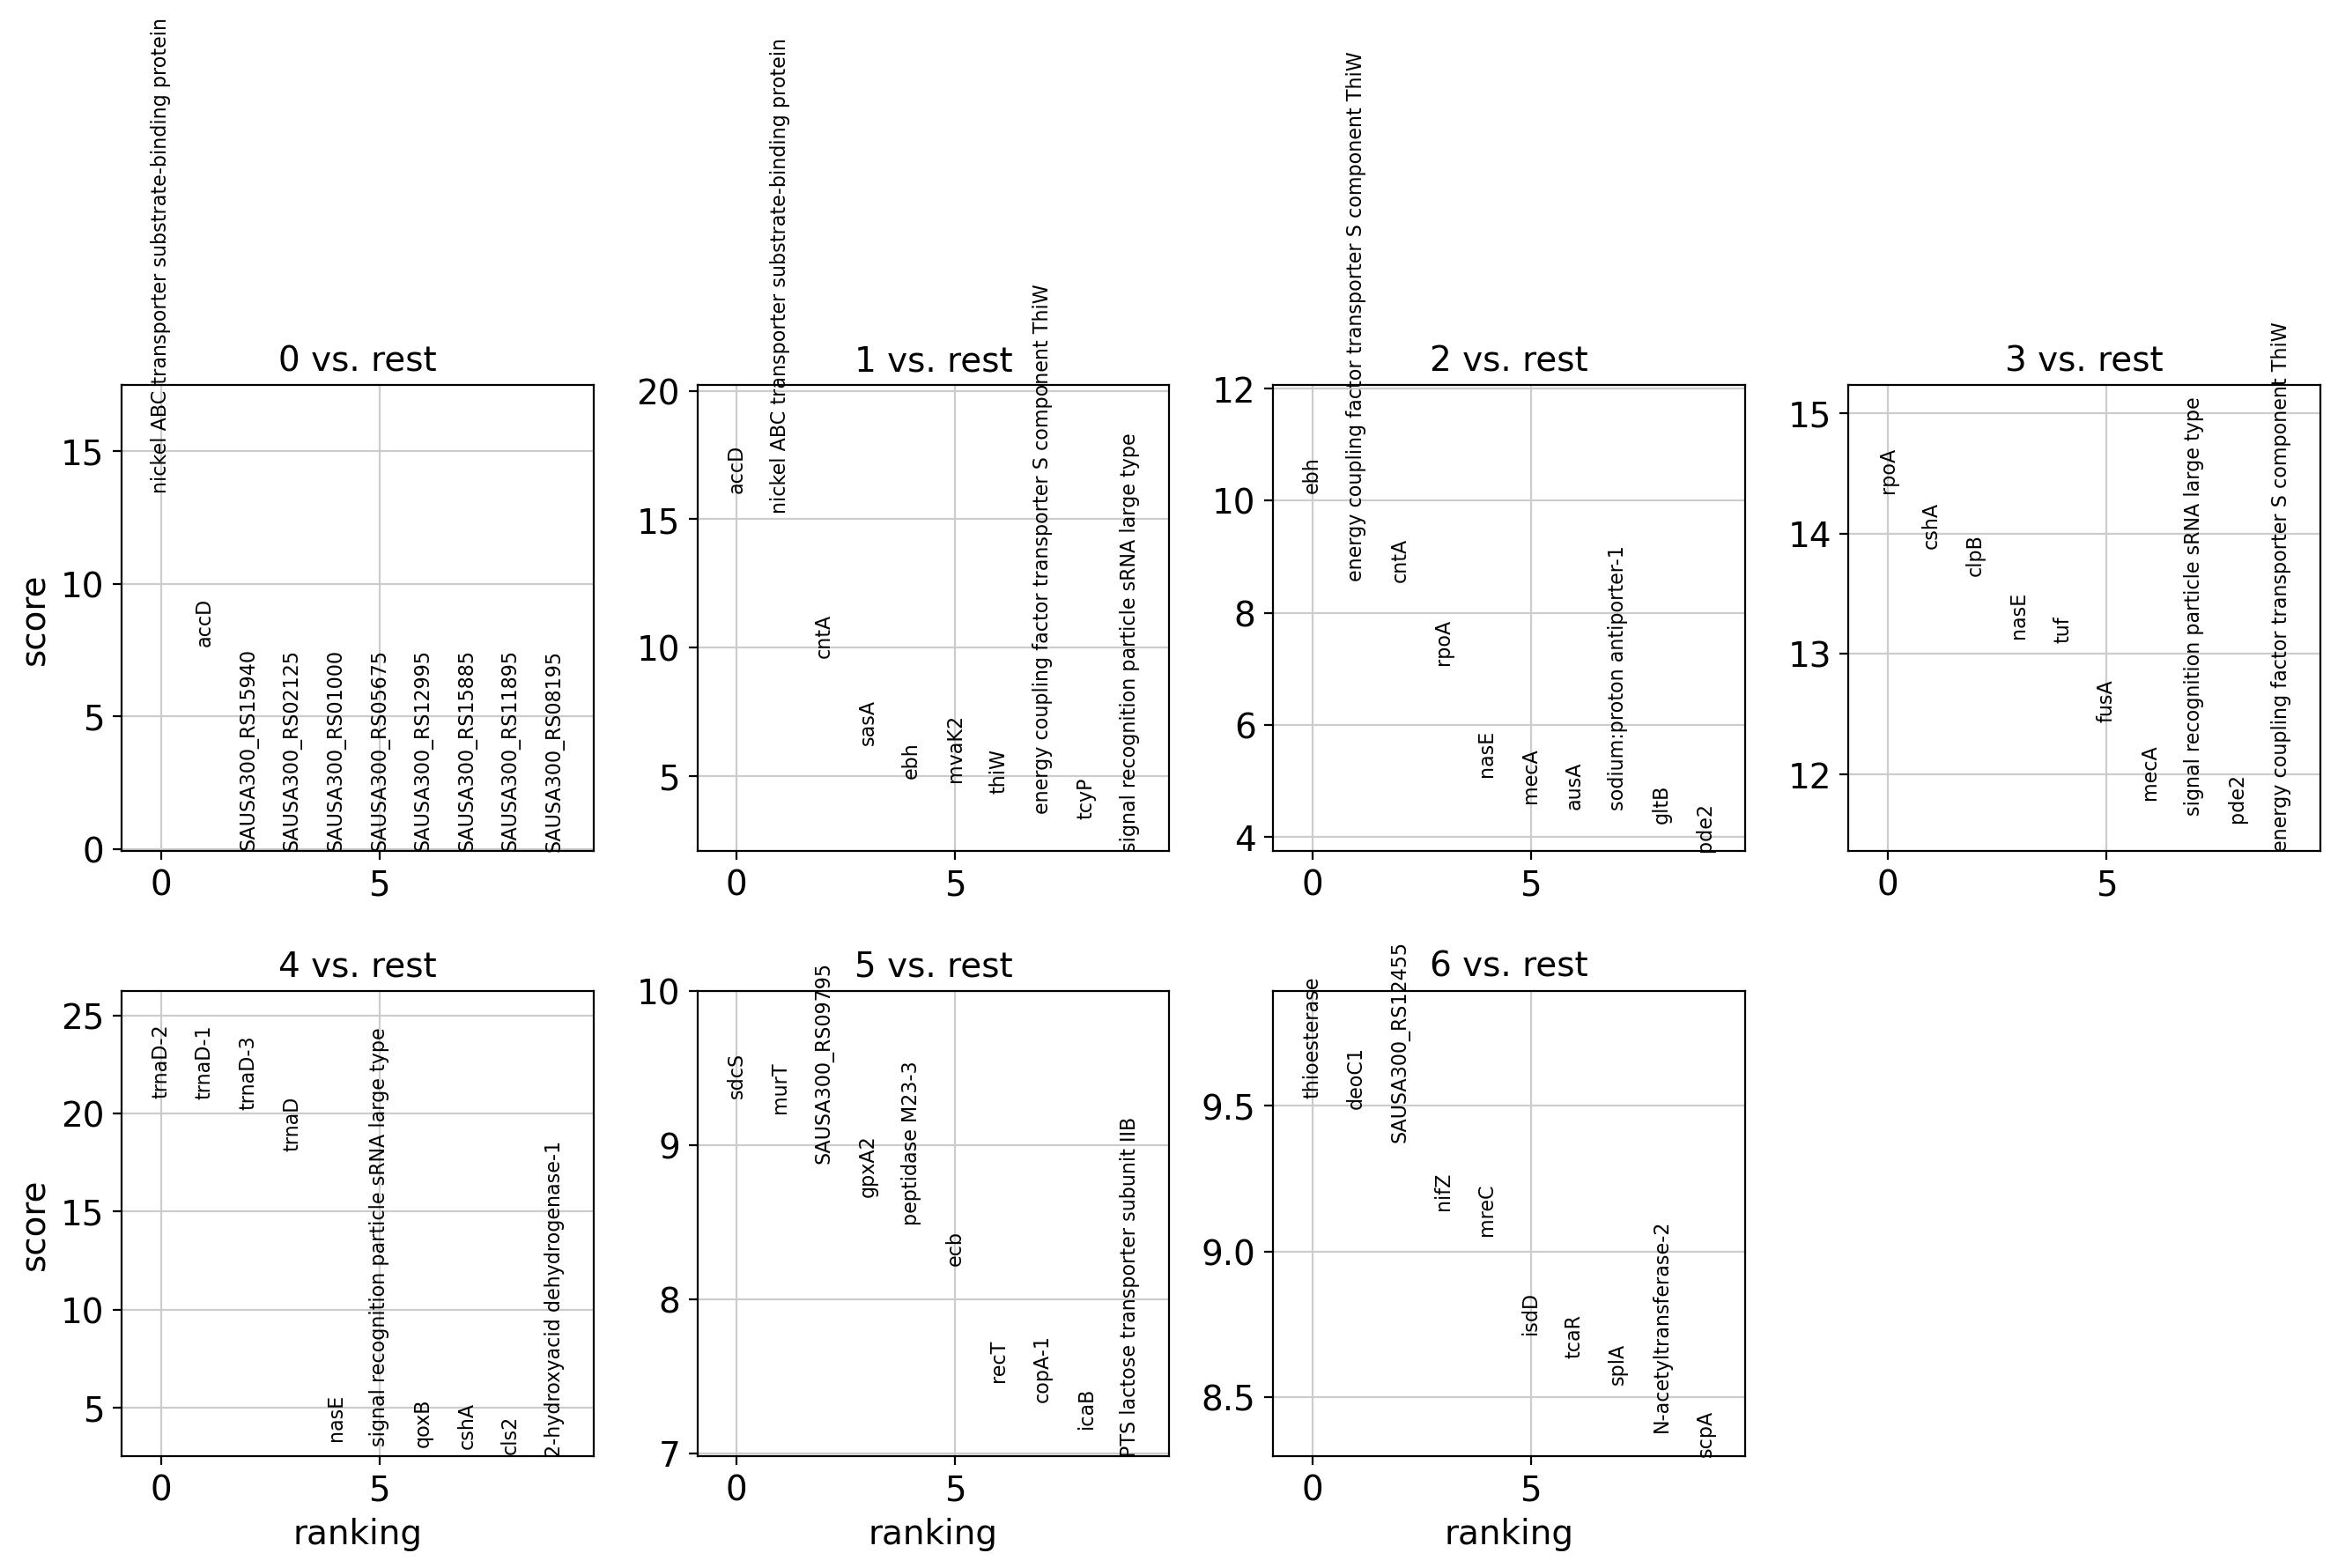

Top marker genes per cluster:
                                                  0  \
0  nickel ABC transporter substrate-binding protein   
1                                              accD   
2                                  SAUSA300_RS15940   
3                                  SAUSA300_RS02125   
4                                  SAUSA300_RS01000   

                                                  1  \
0                                              accD   
1  nickel ABC transporter substrate-binding protein   
2                                              cntA   
3                                              sasA   
4                                               ebh   

                                                   2     3        4  \
0                                                ebh  rpoA  trnaD-2   
1  energy coupling factor transporter S component...  cshA  trnaD-1   
2                                               cntA  clpB  trnaD-3   
3                       

In [28]:
# --- NEW PART 1: IDENTIFYING MARKER GENES ---

# Compute marker genes for each cluster using the Wilcoxon rank-sum test
sc.tl.rank_genes_groups(adata_bacteria, 'leiden', method='wilcoxon')

# Visualize the top 10 marker genes per cluster to assist with annotation
sc.pl.rank_genes_groups(adata_bacteria, n_genes=10, sharey=False)

# Display the top 5 markers per cluster in a readable table format
import pandas as pd
marker_table = pd.DataFrame(adata_bacteria.uns['rank_genes_groups']['names']).head(5)
print("Top marker genes per cluster:")
print(marker_table)

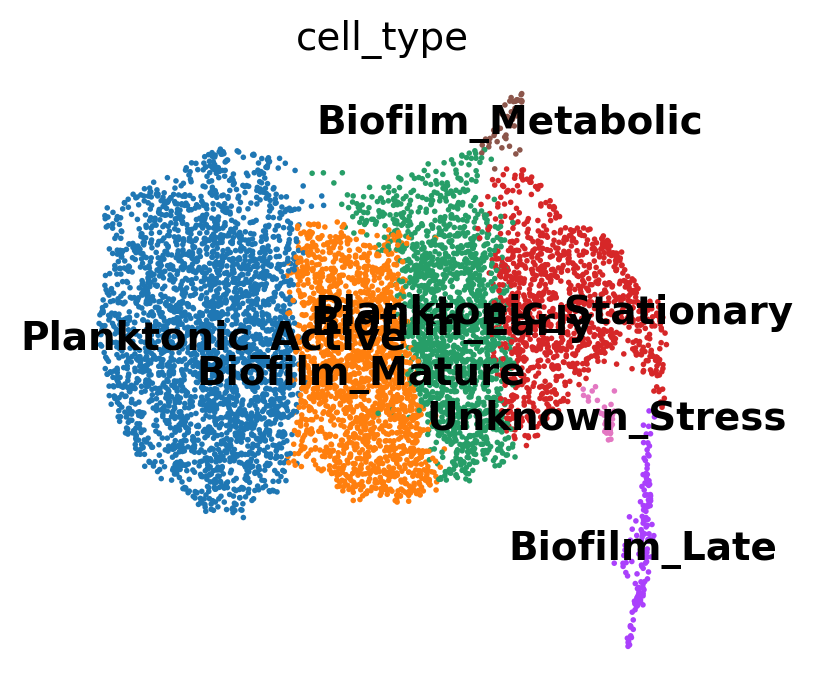

In [29]:
# --- NIEUW STUK 2: NAMEN GEVEN ---
# KIJK NAAR JE MARKERS EN PAS DIT DICTIONARY AAN:
# Voorbeeld: als cluster 0 markers heeft voor planktonische groei:
cluster_namen = {
    '0': 'Planktonic_Active',
    '1': 'Biofilm_Mature',
    '2': 'Biofilm_Early',
    '3': 'Planktonic_Stationary',
    '4': 'Biofilm_Late',
    '5': 'Biofilm_Metabolic',
    '6': 'Unknown_Stress'
}

# Voeg de namen toe aan je data
adata_bacteria.obs['cell_type'] = adata_bacteria.obs['leiden'].map(cluster_namen)

# Check of het gelukt is in de UMAP
sc.pl.umap(adata_bacteria, color='cell_type', legend_loc='on data')

## 7. CellTypist Training (De "Pipeline" stap)

In [30]:
# --- NIEUW STUK 3: CELLTYPIST TRAINING ---
import celltypist

# Train het model op basis van de namen die je net hebt gegeven
# We gebruiken feature_selection=True zodat hij zelf de beste genen kiest
model = celltypist.train(adata_bacteria, 
                         labels = 'cell_type', 
                         feature_selection = True, 
                         top_genes = 300)

# Sla je model op zodat je het nooit meer opnieuw hoeft te doen!
model.write('Staph_Aureus_BF_P_Model.pkl')

print("Model succesvol getraind en opgeslagen!")

🍳 Preparing data before training
👀 Detected scaled expression in the input data, will try the .raw attribute
🔬 Input data has 7437 cells and 2799 genes
⚖️ Scaling input data
🏋️ Training data using SGD logistic regression
🔎 Selecting features
🧬 1488 features are selected
🏋️ Starting the second round of training
🏋️ Training data using logistic regression
✅ Model training done!


Model succesvol getraind en opgeslagen!
